# Validação Externa — 2025 (Ano Endêmico)
Avalia os modelos treinados (2020–2023) no conjunto de 2025, ano endêmico.
Comparação direta com os resultados de 2024 (ano epidêmico) para medir robustez e generalização.
**Scores brutos — sem calibração aplicada.**

**Métricas prioritárias:** Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1

In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, average_precision_score,
    roc_auc_score, precision_score, f1_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)

BASE_DIR    = '../../data/processed'
BASE_2024   = '../../data/features/baseline'
OUTPUT_MOD  = '../../output/modelos'
OUTPUT_MET  = '../../output/metricas'
OUTPUT_PLT  = '../../output/plots'
YEAR_COL    = 'year'
os.makedirs(OUTPUT_PLT, exist_ok=True)

def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL, 'target'], errors='ignore')

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
    }

## 1. Carregamento dos dados de 2025

In [6]:
df_2025 = pd.read_parquet(os.path.join(BASE_DIR, 'dengue_2025_treated.parquet'))

y_2025 = df_2025['target'].dropna()
mask   = df_2025['target'].notna().values
X_2025 = prep_X(df_2025)

print(f'2025 — Total: {len(df_2025):,} | Óbitos: {int(y_2025.sum()):,} ({y_2025.mean()*100:.2f}%)')

# Referência 2024
y_2024 = pd.read_parquet(os.path.join(BASE_2024, 'y_test.parquet')).squeeze().dropna()
print(f'2024 — Total: {len(y_2024):,} | Óbitos: {int(y_2024.sum()):,} ({y_2024.mean()*100:.2f}%)')

2025 — Total: 63,271 | Óbitos: 1,539 (2.43%)
2024 — Total: 160,534 | Óbitos: 5,295 (3.30%)


## 2. Carregamento dos modelos

In [7]:
modelos = {
    'LR':                   joblib.load(os.path.join(OUTPUT_MOD, 'logistic_regression_baseline.joblib')),
    'LR (tuned)':           joblib.load(os.path.join(OUTPUT_MOD, 'logistic_regression_baseline_tuned.joblib')),
    'MLP':                  joblib.load(os.path.join(OUTPUT_MOD, 'mlp_baseline.joblib')),
    'LightGBM':             joblib.load(os.path.join(OUTPUT_MOD, 'lightgbm_baseline.joblib')),
    'LightGBM (tuned)':     joblib.load(os.path.join(OUTPUT_MOD, 'lightgbm_baseline_tuned.joblib')),
    'XGBoost':              joblib.load(os.path.join(OUTPUT_MOD, 'xgboost_baseline.joblib')),
    'XGBoost (tuned)':      joblib.load(os.path.join(OUTPUT_MOD, 'xgboost_baseline_tuned.joblib')),
    'Random Forest':        joblib.load(os.path.join(OUTPUT_MOD, 'random_forest_baseline.joblib')),
    'Random Forest (tuned)':joblib.load(os.path.join(OUTPUT_MOD, 'random_forest_baseline_tuned.joblib')),
}

print('Modelos carregados:', list(modelos.keys()))

Modelos carregados: ['LR', 'LR (tuned)', 'MLP', 'LightGBM', 'LightGBM (tuned)', 'XGBoost', 'XGBoost (tuned)', 'Random Forest', 'Random Forest (tuned)']


## 3. Predições e métricas — 2025

In [8]:
resultados_2025 = {}

print(f'{'Modelo':<25} {'Sensibilidade':>14} {'AUPRC':>8} {'ROC-AUC':>9} {'Especif.':>10}')
print('-' * 70)

for nome, modelo in modelos.items():
    proba = modelo.predict_proba(X_2025)[:, 1][mask]
    m     = calcular_metricas(y_2025, proba)
    resultados_2025[nome] = {'proba': proba, 'metricas': m}
    print(f'{nome:<25} {m["sensibilidade"]:>14.4f} {m["auprc"]:>8.4f} '
          f'{m["roc_auc"]:>9.4f} {m["especificidade"]:>10.4f}')

Modelo                     Sensibilidade    AUPRC   ROC-AUC   Especif.
----------------------------------------------------------------------
LR                                0.7888   0.5862    0.9188     0.8940
LR (tuned)                        0.7882   0.5861    0.9188     0.8939
MLP                               0.7609   0.5951    0.9170     0.9175
LightGBM                          0.6530   0.5570    0.8984     0.9586
LightGBM (tuned)                  0.7290   0.5800    0.9109     0.9312
XGBoost                           0.7329   0.5630    0.9093     0.9212
XGBoost (tuned)                   0.7791   0.5798    0.9186     0.9012
Random Forest                     0.6121   0.5863    0.9168     0.9843
Random Forest (tuned)             0.4483   0.5845    0.8993     0.9971


## 4. Comparação 2024 vs 2025

In [9]:
# Carrega métricas de 2024 do CSV já salvo
df_2024 = pd.read_csv(os.path.join(OUTPUT_MET, 'COMPARACAO_TODOS_MODELOS.csv'))
df_2024 = df_2024[df_2024['modelo'].isin(modelos.keys())].set_index('modelo')

rows_comp = []
for nome, res in resultados_2025.items():
    m25 = res['metricas']
    if nome not in df_2024.index:
        continue
    m24 = df_2024.loc[nome]
    rows_comp.append({
        'modelo':          nome,
        'sens_2024':       m24['sensibilidade'],
        'sens_2025':       m25['sensibilidade'],
        'delta_sens':      round(m25['sensibilidade'] - m24['sensibilidade'], 4),
        'auprc_2024':      m24['auprc'],
        'auprc_2025':      m25['auprc'],
        'delta_auprc':     round(m25['auprc'] - m24['auprc'], 4),
        'roc_auc_2024':    m24['roc_auc'],
        'roc_auc_2025':    m25['roc_auc'],
        'delta_roc':       round(m25['roc_auc'] - m24['roc_auc'], 4),
    })

df_comp = pd.DataFrame(rows_comp).sort_values('sens_2025', ascending=False).reset_index(drop=True)

print(f'{'Modelo':<25} {'Sens 24':>8} {'Sens 25':>8} {'Δ Sens':>8} '
      f'{'AUPRC 24':>10} {'AUPRC 25':>10} {'Δ AUPRC':>9}')
print('-' * 85)
for _, r in df_comp.iterrows():
    sinal_s = '+' if r['delta_sens'] >= 0 else ''
    sinal_a = '+' if r['delta_auprc'] >= 0 else ''
    print(f'{r["modelo"]:<25} {r["sens_2024"]:>8.4f} {r["sens_2025"]:>8.4f} '
          f'{sinal_s}{r["delta_sens"]:>7.4f} {r["auprc_2024"]:>10.4f} '
          f'{r["auprc_2025"]:>10.4f} {sinal_a}{r["delta_auprc"]:>8.4f}')

Modelo                     Sens 24  Sens 25   Δ Sens   AUPRC 24   AUPRC 25   Δ AUPRC
-------------------------------------------------------------------------------------
LR                          0.7870   0.7888 + 0.0018     0.6067     0.5862  -0.0205
LR (tuned)                  0.8008   0.7882 -0.0126     0.6250     0.5861  -0.0389
XGBoost (tuned)             0.7932   0.7791 -0.0141     0.6314     0.5798  -0.0516
MLP                         0.7843   0.7609 -0.0234     0.6369     0.5951  -0.0418
XGBoost                     0.7490   0.7329 -0.0161     0.6112     0.5630  -0.0482
LightGBM (tuned)            0.7549   0.7290 -0.0259     0.6294     0.5800  -0.0494
LightGBM                    0.6820   0.6530 -0.0290     0.6098     0.5570  -0.0528
Random Forest               0.6240   0.6121 -0.0119     0.6276     0.5863  -0.0413
Random Forest (tuned)       0.4457   0.4483 + 0.0026     0.6268     0.5845  -0.0423


## 5. Gráfico comparativo

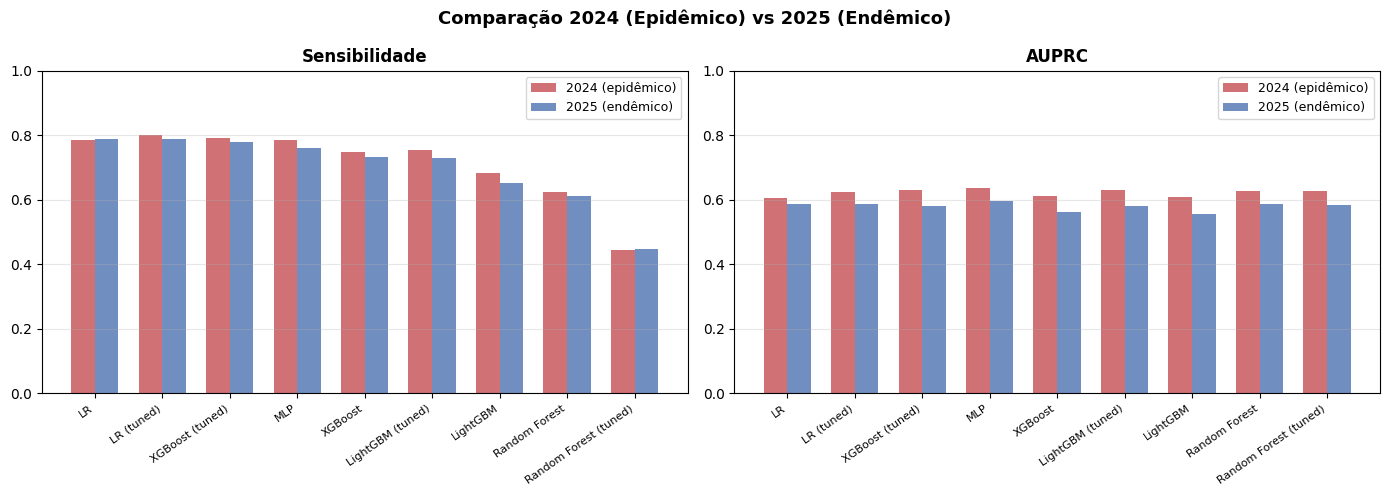

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(len(df_comp))
nomes = df_comp['modelo'].tolist()
w     = 0.35

for ax, (m24_col, m25_col, titulo) in zip(axes, [
    ('sens_2024',  'sens_2025',  'Sensibilidade'),
    ('auprc_2024', 'auprc_2025', 'AUPRC'),
]):
    ax.bar(x - w/2, df_comp[m24_col], w, label='2024 (epidêmico)', color='#C44E52', alpha=0.8)
    ax.bar(x + w/2, df_comp[m25_col], w, label='2025 (endêmico)',  color='#4C72B0', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(nomes, rotation=35, ha='right', fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparação 2024 (Epidêmico) vs 2025 (Endêmico)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'validacao_2025_comparacao.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Curvas ROC e Precision-Recall — 2025

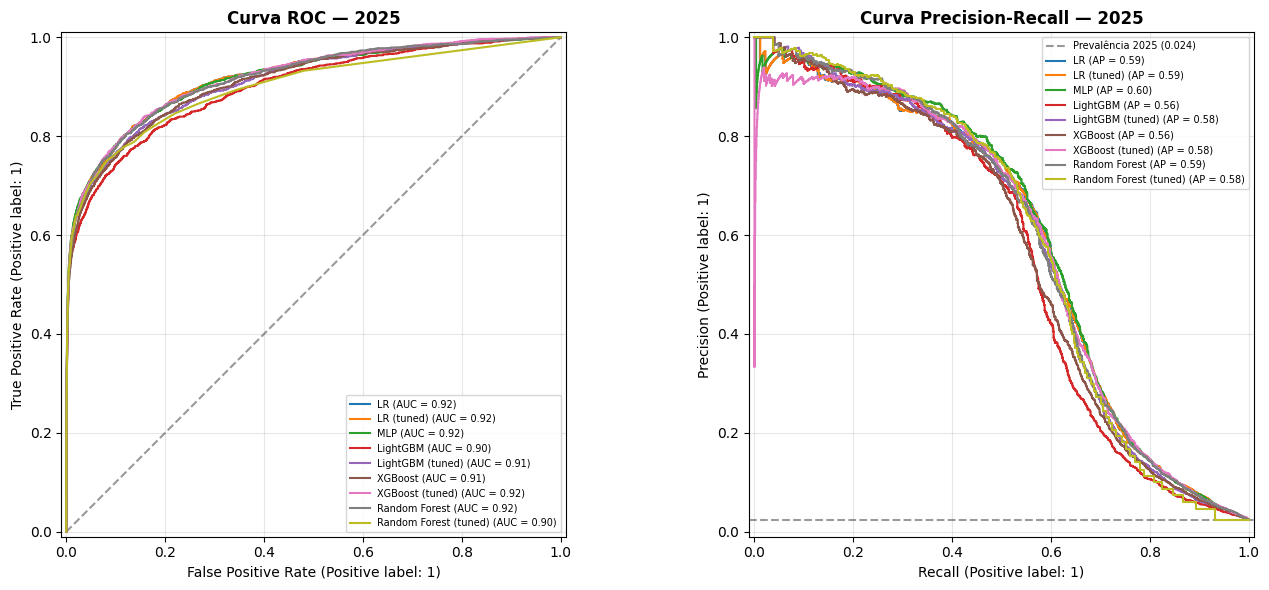

In [11]:
cmap   = plt.get_cmap('tab10')
colors = {nome: cmap(i) for i, nome in enumerate(modelos.keys())}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
prev_2025 = float(y_2025.mean())
axes[1].axhline(prev_2025, color='k', linestyle='--', alpha=0.4,
                label=f'Prevalência 2025 ({prev_2025:.3f})')

for nome, res in resultados_2025.items():
    RocCurveDisplay.from_predictions(
        y_2025, res['proba'], ax=axes[0], name=nome,
        color=colors[nome], lw=1.5,
    )
    PrecisionRecallDisplay.from_predictions(
        y_2025, res['proba'], ax=axes[1], name=nome,
        color=colors[nome], lw=1.5,
    )

axes[0].set_title('Curva ROC — 2025', fontweight='bold')
axes[1].set_title('Curva Precision-Recall — 2025', fontweight='bold')
for ax in axes:
    ax.legend(fontsize=7, loc='lower right' if ax == axes[0] else 'upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'validacao_2025_curvas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvamento

In [12]:
# Métricas 2025
rows_met = []
for nome, res in resultados_2025.items():
    rows_met.append({'modelo': nome, 'dataset': '2025_endemico', **res['metricas']})

df_met_2025 = pd.DataFrame(rows_met).sort_values('auprc', ascending=False)
met_path = os.path.join(OUTPUT_MET, 'COMPARACAO_2025.csv')
df_met_2025.to_csv(met_path, index=False)
print(f'Métricas 2025 salvas: {met_path}')

# Predições 2025 por modelo
for nome, res in resultados_2025.items():
    label = nome.lower().replace(' ', '_').replace('(', '').replace(')', '')
    df_pred = pd.DataFrame({'y_true': y_2025.values, 'y_proba': res['proba']})
    pred_path = os.path.join(OUTPUT_MET, f'{label}_2025_predicoes.parquet')
    df_pred.to_parquet(pred_path, index=False)

print(f'Predições 2025 salvas em {OUTPUT_MET}/')

# Comparação 2024 vs 2025
comp_path = os.path.join(OUTPUT_MET, 'COMPARACAO_2024_vs_2025.csv')
df_comp.to_csv(comp_path, index=False)
print(f'Comparação salva: {comp_path}')

Métricas 2025 salvas: ../../output/metricas/COMPARACAO_2025.csv
Predições 2025 salvas em ../../output/metricas/
Comparação salva: ../../output/metricas/COMPARACAO_2024_vs_2025.csv


## 8. Conclusão

### Contexto
Os modelos foram treinados em dados de 2020–2023 e avaliados em dois contextos distintos:
- **2024 — Ano epidêmico:** 160.534 registros | 5.295 óbitos | prevalência 3,30%
- **2025 — Ano endêmico:** 63.271 registros | 1.539 óbitos | prevalência 2,43%

### Degradação de performance
Todos os modelos apresentam queda consistente de AUPRC (~0.04–0.05) no contexto endêmico. Isso é esperado: anos endêmicos têm distribuição de severidade diferente, com menos casos graves, tornando a discriminação intrinsecamente mais difícil.

### Robustez por modelo
| Modelo | Δ Sensibilidade | Δ AUPRC | Avaliação |
|---|---|---|---|
| **LR** | +0.0018 | -0.0205 | Mais robusto — generaliza bem entre contextos |
| **LR (tuned)** | -0.0126 | -0.0389 | Estável, leve degradação pelo tuning |
| **Random Forest** | -0.0119 | -0.0413 | Estável em sensibilidade |
| **MLP** | -0.0234 | -0.0418 | Degradação moderada |
| **XGBoost (tuned)** | -0.0141 | -0.0516 | Maior queda de AUPRC entre os tuned |
| **LightGBM (tuned)** | -0.0259 | -0.0494 | Mais afetado entre os modelos principais |

### Interpretação
Modelos mais complexos (LightGBM, XGBoost) aprendem padrões mais específicos do período de treino (2020–2023, majoritariamente epidêmico), o que reduz sua capacidade de generalizar para o contexto endêmico. A LR, por ser mais simples e regularizada, captura padrões mais estáveis e transferíveis entre contextos epidemiológicos.

### Implicação para escolha do modelo final
A **LR baseline** apresenta o melhor equilíbrio entre:
- Sensibilidade competitiva em 2024 (epidêmico)
- Maior robustez em 2025 (endêmico)
- Interpretabilidade dos coeficientes
- Menor risco de overfitting a padrões sazonais específicos

A queda de AUPRC em 2025 é uma limitação inerente ao problema — não há indicação de que outro modelo a resolva de forma superior.